In [16]:
import pandas as pd

data = {
    "Attendance": ["High","High","Medium","Low","Low","Medium","High","Medium","High","Low","Medium","High"],
    "Assignment": ["Yes","Yes","Yes","No","No","Yes","No","No","Yes","Yes","No","Yes"],
    "Study Hours": ["High","Medium","High","Low","Medium","Medium","High","Low","Medium","Low","Medium","High"],
    "Previous Grade": ["Good","Good","Average","Poor","Poor","Average","Good","Poor","Average","Poor","Average","Good"],
    "Result": ["Pass","Pass","Pass","Fail","Fail","Pass","Pass","Fail","Pass","Fail","Fail","Pass"]
}

df = pd.DataFrame(data)

display(df)

,Attendance,Assignment,Study Hours,Previous Grade,Result
0,High,Yes,High,Good,Pass
1,High,Yes,Medium,Good,Pass
2,Medium,Yes,High,Average,Pass
3,Low,No,Low,Poor,Fail
4,Low,No,Medium,Poor,Fail
5,Medium,Yes,Medium,Average,Pass
6,High,No,High,Good,Pass
7,Medium,No,Low,Poor,Fail
8,High,Yes,Medium,Average,Pass
9,Low,Yes,Low,Poor,Fail


In [17]:
predictor_attributes = list(df.columns[:-1])

target_attribute = df.columns[-1]

print("Predictor Attributes")
print(predictor_attributes)

print("\nTarget Attribute")
print(target_attribute)

print("\nTotal Records")
print(len(df))

print("\nTarget Classes")
print(df[target_attribute].unique())

print("\nNumber of Target Classes")
print(df[target_attribute].nunique())

Predictor Attributes
['Attendance', 'Assignment', 'Study Hours', 'Previous Grade']

Target Attribute
Result

Total Records
12

Target Classes
['Pass' 'Fail']

Number of Target Classes
2


In [18]:
#Entropy calculation

from math import log2

def entropy(column):
    values = column.value_counts(normalize=True)
    return -sum(p * log2(p) for p in values)

dataset_entropy = entropy(df["Result"])

print("Entropy of Dataset")
print(round(dataset_entropy,4))

Entropy of Dataset
0.9799


In [19]:
def attribute_entropy(attribute):

    total = len(df)

    ent = 0

    for value in df[attribute].unique():

        subset = df[df[attribute] == value]

        weight = len(subset) / total

        ent += weight * entropy(subset["Result"])

    return ent

entropy_table = pd.DataFrame({
    "Attribute": predictor_attributes,
    "Entropy": [round(attribute_entropy(col),4) for col in predictor_attributes]
})

display(entropy_table)

,Attribute,Entropy
0,Attendance,0.3333
1,Assignment,0.6459
2,Study Hours,0.4046
3,Previous Grade,0.2704


In [20]:
#INTERMEDIATE ENTROPY CALCULATIONS
print("INTERMEDIATE ENTROPY CALCULATIONS\n")

for attribute in predictor_attributes:


    print("Attribute :", attribute)

    weighted_entropy = 0

    for value in df[attribute].unique():

        subset = df[df[attribute] == value]

        total = len(subset)

        pass_count = len(subset[subset["Result"] == "Pass"])
        fail_count = len(subset[subset["Result"] == "Fail"])

        p_pass = pass_count / total if total else 0
        p_fail = fail_count / total if total else 0

        ent = 0

        if p_pass > 0:
            ent -= p_pass * log2(p_pass)

        if p_fail > 0:
            ent -= p_fail * log2(p_fail)

        weight = total / len(df)

        weighted_entropy += weight * ent

        print(f"\n{value}")
        print(f"Pass : {pass_count}")
        print(f"Fail : {fail_count}")
        print(f"P(Pass) = {round(p_pass,3)}")
        print(f"P(Fail) = {round(p_fail,3)}")
        print(f"Entropy = {round(ent,4)}")
        print(f"Weighted Entropy = {round(weight*ent,4)}")

    print("\nFinal Weighted Entropy =", round(weighted_entropy,4))

INTERMEDIATE ENTROPY CALCULATIONS

Attribute : Attendance

High
Pass : 5
Fail : 0
P(Pass) = 1.0
P(Fail) = 0.0
Entropy = 0.0
Weighted Entropy = 0.0

Medium
Pass : 2
Fail : 2
P(Pass) = 0.5
P(Fail) = 0.5
Entropy = 1.0
Weighted Entropy = 0.3333

Low
Pass : 0
Fail : 3
P(Pass) = 0.0
P(Fail) = 1.0
Entropy = 0.0
Weighted Entropy = 0.0

Final Weighted Entropy = 0.3333
Attribute : Assignment

Yes
Pass : 6
Fail : 1
P(Pass) = 0.857
P(Fail) = 0.143
Entropy = 0.5917
Weighted Entropy = 0.3451

No
Pass : 1
Fail : 4
P(Pass) = 0.2
P(Fail) = 0.8
Entropy = 0.7219
Weighted Entropy = 0.3008

Final Weighted Entropy = 0.6459
Attribute : Study Hours

High
Pass : 4
Fail : 0
P(Pass) = 1.0
P(Fail) = 0.0
Entropy = 0.0
Weighted Entropy = 0.0

Medium
Pass : 3
Fail : 2
P(Pass) = 0.6
P(Fail) = 0.4
Entropy = 0.971
Weighted Entropy = 0.4046

Low
Pass : 0
Fail : 3
P(Pass) = 0.0
P(Fail) = 1.0
Entropy = 0.0
Weighted Entropy = 0.0

Final Weighted Entropy = 0.4046
Attribute : Previous Grade

Good
Pass : 4
Fail : 0
P(Pass) = 

In [21]:
#information gain
entropy_table["Information Gain"] = round(
    dataset_entropy - entropy_table["Entropy"],4
)

display(entropy_table)

best_id3 = entropy_table.sort_values(
    by="Information Gain",
    ascending=False
).iloc[0]

print("Root Node using ID3")

print(best_id3["Attribute"])

,Attribute,Entropy,Information Gain
0,Attendance,0.3333,0.6466
1,Assignment,0.6459,0.3340
2,Study Hours,0.4046,0.5753
3,Previous Grade,0.2704,0.7095


Root Node using ID3
Previous Grade


In [22]:
#Gain ratio(c4.5)
def split_info(attribute):

    values = df[attribute].value_counts(normalize=True)

    return -sum(p * log2(p) for p in values)

entropy_table["Split Information"] = [
    round(split_info(col),4)
    for col in predictor_attributes
]

entropy_table["Gain Ratio"] = round(
    entropy_table["Information Gain"] /
    entropy_table["Split Information"],
    4
)

display(entropy_table)

best_c45 = entropy_table.sort_values(
    by="Gain Ratio",
    ascending=False
).iloc[0]

print("Root Node using C4.5")

print(best_c45["Attribute"])

,Attribute,Entropy,Information Gain,Split Information,Gain Ratio
0,Attendance,0.3333,0.6466,1.5546,0.4159
1,Assignment,0.6459,0.3340,0.9799,0.3409
2,Study Hours,0.4046,0.5753,1.5546,0.3701
3,Previous Grade,0.2704,0.7095,1.5850,0.4476


Root Node using C4.5
Previous Grade


In [23]:
#Gini Index(CART)

def gini(attribute):

    total = len(df)

    gini_value = 0

    for value in df[attribute].unique():

        subset = df[df[attribute] == value]

        weight = len(subset) / total

        probs = subset["Result"].value_counts(normalize=True)

        g = 1 - sum(p**2 for p in probs)

        gini_value += weight * g

    return gini_value

entropy_table["Gini Index"] = [
    round(gini(col),4)
    for col in predictor_attributes
]

display(entropy_table)

best_cart = entropy_table.sort_values(
    by="Gini Index"
).iloc[0]

print("Root Node using CART")

print(best_cart["Attribute"])

,Attribute,Entropy,Information Gain,Split Information,Gain Ratio,Gini Index
0,Attendance,0.3333,0.6466,1.5546,0.4159,0.1667
1,Assignment,0.6459,0.3340,0.9799,0.3409,0.2762
2,Study Hours,0.4046,0.5753,1.5546,0.3701,0.2000
3,Previous Grade,0.2704,0.7095,1.5850,0.4476,0.1250


Root Node using CART
Previous Grade


In [24]:
#comparative analysis


print(f"ID3 Root Node   : {best_id3['Attribute']}")
print(f"C4.5 Root Node  : {best_c45['Attribute']}")
print(f"CART Root Node  : {best_cart['Attribute']}")

print("\nExplanation")

if best_id3["Attribute"] == best_c45["Attribute"] == best_cart["Attribute"]:
    print("All three algorithms selected the same root node because it provides the best split according to their respective measures.")
else:
    print("The algorithms selected different root nodes because each uses a different attribute selection measure.")

print("\nAttribute Selection Measures")

print("ID3  -> Information Gain")
print("C4.5 -> Gain Ratio")
print("CART -> Gini Index")

ID3 Root Node   : Previous Grade
C4.5 Root Node  : Previous Grade
CART Root Node  : Previous Grade

Explanation
All three algorithms selected the same root node because it provides the best split according to their respective measures.

Attribute Selection Measures
ID3  -> Information Gain
C4.5 -> Gain Ratio
CART -> Gini Index


In [25]:
#justification
print("ID3 JUSTIFICATION")
print(f"{best_id3['Attribute']} is selected because it has the highest Information Gain ({best_id3['Information Gain']}).")
print("Higher Information Gain means greater reduction in uncertainty.\n")

print("C4.5 JUSTIFICATION")
print(f"{best_c45['Attribute']} is selected because it has the highest Gain Ratio ({best_c45['Gain Ratio']}).")
print("Gain Ratio removes the bias of Information Gain towards attributes with many values.\n")

print("CART JUSTIFICATION")
print(f"{best_cart['Attribute']} is selected because it has the lowest Gini Index ({best_cart['Gini Index']}).")
print("Lower Gini Index indicates better class purity after splitting.")

ID3 JUSTIFICATION
Previous Grade is selected because it has the highest Information Gain (0.7095).
Higher Information Gain means greater reduction in uncertainty.

C4.5 JUSTIFICATION
Previous Grade is selected because it has the highest Gain Ratio (0.4476).
Gain Ratio removes the bias of Information Gain towards attributes with many values.

CART JUSTIFICATION
Previous Grade is selected because it has the lowest Gini Index (0.125).
Lower Gini Index indicates better class purity after splitting.


In [26]:
#comparative analysis
comparison = pd.DataFrame({
    "Algorithm":["ID3","C4.5","CART"],
    "Root Node":[
        best_id3["Attribute"],
        best_c45["Attribute"],
        best_cart["Attribute"]
    ]
})

display(comparison)

,Algorithm,Root Node
0,ID3,Previous Grade
1,C4.5,Previous Grade
2,CART,Previous Grade


In [27]:
#strength and limitation
comparison_table = pd.DataFrame({

    "Measure":[
        "Information Gain",
        "Gain Ratio",
        "Gini Index"
    ],

    "Strength":[
        "Easy to understand and reduces entropy effectively.",
        "Removes the bias of Information Gain.",
        "Fast and computationally efficient."
    ],

    "Limitation":[
        "Can favor attributes with many unique values.",
        "Requires additional Split Information calculation.",
        "Does not measure information content like entropy."
    ]

})

display(comparison_table)

,Measure,Strength,Limitation
0,Information Gain,Easy to understand and reduces entropy effecti...,Can favor attributes with many unique values.
1,Gain Ratio,Removes the bias of Information Gain.,Requires additional Split Information calculat...
2,Gini Index,Fast and computationally efficient.,Does not measure information content like entr...


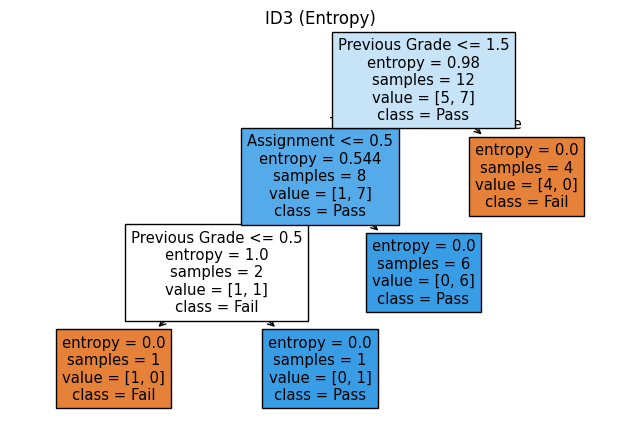

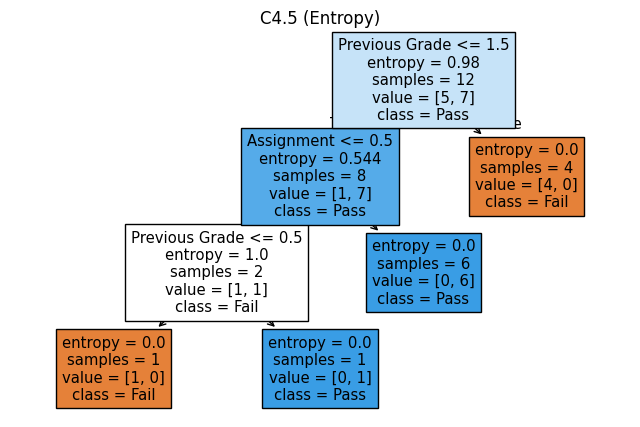

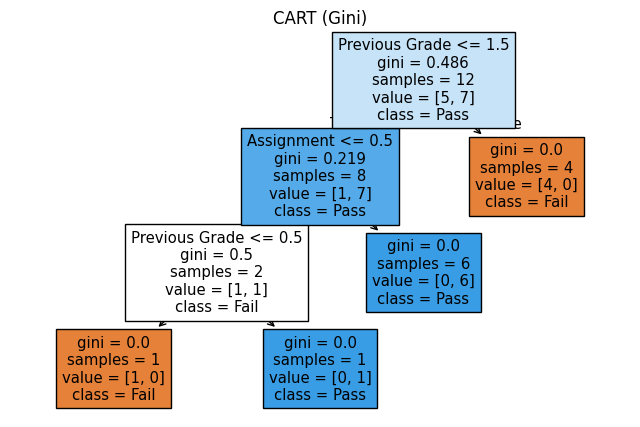

In [28]:
#construction of decision tree
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

import matplotlib.pyplot as plt

encoded_df = df.copy()

encoders = {}

for col in encoded_df.columns:

    encoder = LabelEncoder()

    encoded_df[col] = encoder.fit_transform(encoded_df[col])

    encoders[col] = encoder

X = encoded_df.drop("Result", axis=1)

y = encoded_df["Result"]

criteria = {
    "ID3 (Entropy)":"entropy",
    "C4.5 (Entropy)":"entropy",
    "CART (Gini)":"gini"
}

for title, criterion in criteria.items():

    model = DecisionTreeClassifier(
        criterion=criterion,
        random_state=42
    )

    model.fit(X,y)

    plt.figure(figsize=(8,5))

    plot_tree(
        model,
        feature_names=X.columns,
        class_names=encoders["Result"].classes_,
        filled=True
    )

    plt.title(title)

    plt.show()

In [29]:
#decision tree comparison

print("DECISION TREE COMPARISON")


print("ID3")
print("- Uses Information Gain")
print("- Uses Entropy for splitting")

print("\nC4.5")
print("- Uses Gain Ratio")
print("- Improves upon ID3 by reducing attribute bias")

print("\nCART")
print("- Uses Gini Index")
print("- Produces binary decision trees")

print("\nObservation")

print("ID3 and C4.5 are entropy-based algorithms, whereas CART uses Gini Index.")
print("CART generally creates binary splits, while ID3 and C4.5 may create multiple branches.")

DECISION TREE COMPARISON
ID3
- Uses Information Gain
- Uses Entropy for splitting

C4.5
- Uses Gain Ratio
- Improves upon ID3 by reducing attribute bias

CART
- Uses Gini Index
- Produces binary decision trees

Observation
ID3 and C4.5 are entropy-based algorithms, whereas CART uses Gini Index.
CART generally creates binary splits, while ID3 and C4.5 may create multiple branches.


In [30]:
#final observation

print("FINAL OBSERVATIONS")


print(f"Dataset Entropy : {round(dataset_entropy,4)}")

print(f"\nBest Attribute using ID3   : {best_id3['Attribute']}")
print(f"Best Attribute using C4.5  : {best_c45['Attribute']}")
print(f"Best Attribute using CART  : {best_cart['Attribute']}")

print("\nOverall Summary")

print("- Information Gain measures reduction in entropy.")
print("- Gain Ratio improves Information Gain by reducing bias.")
print("- Gini Index measures node impurity.")
print("- Decision Trees use these measures to choose the best root node.")
print("- Different algorithms may choose different attributes depending on their splitting criterion.")

print("\nNote")

print("Scikit-learn does not provide native implementations of ID3 and C4.5.")
print("Therefore, entropy-based decision trees are used to demonstrate these algorithms, while CART is implemented using the Gini criterion.")

FINAL OBSERVATIONS
Dataset Entropy : 0.9799

Best Attribute using ID3   : Previous Grade
Best Attribute using C4.5  : Previous Grade
Best Attribute using CART  : Previous Grade

Overall Summary
- Information Gain measures reduction in entropy.
- Gain Ratio improves Information Gain by reducing bias.
- Gini Index measures node impurity.
- Decision Trees use these measures to choose the best root node.
- Different algorithms may choose different attributes depending on their splitting criterion.

Note
Scikit-learn does not provide native implementations of ID3 and C4.5.
Therefore, entropy-based decision trees are used to demonstrate these algorithms, while CART is implemented using the Gini criterion.


Learning Outcome:
From this experiment, I learned how Decision Tree algorithms select the best attribute for splitting a dataset using different attribute selection measures. I also understood how to calculate Entropy, Information Gain, Gain Ratio and Gini Index and how each measure influences the choice of the root node. I also learned to implement decision tree algorithms in Python, visualise the generated trees and compare the performance of ID3, C4.5 and CART.